# Results Analysis

Loads all per-run JSON files from `results/`, builds comparison tables and plots.

**Datasets:** optdigits · mnist · landsat · backdoor  
**Variants:** 14 per dataset (4 teachers × up to 3 routing strategies + vanilla baseline)  
**Seeds:** 42, 123, 456

In [36]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path('../results')
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ['optdigits', 'mnist', 'landsat', 'backdoor']
TEACHERS = ['vanilla', 'cnn', 'transformer', 'vae']
BASELINE = 'kitsune_vanilla'

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

In [37]:
# Load all result JSON files (skip sweep/ subdirectory)
records = []
for f in RESULTS_DIR.glob('*.json'):
    with open(f) as fh:
        records.append(json.load(fh))

df = pd.DataFrame(records)

# Keep only the 4 target datasets
df = df[df['dataset'].isin(DATASETS)]

print(f'Loaded {len(df)} results across {df["dataset"].nunique()} datasets and {df["model"].nunique()} model variants')
df.head()

Loaded 168 results across 4 datasets and 14 model variants


,auc_roc,auc_pr,f1_oracle,params,inference_time_ms,phi,f1_phi,dataset,model,seed
0,0.321239,0.017456,0.056794,137025,0.157387,0.041017,0.000000,backdoor,cnn,123
1,0.320531,0.017443,0.056792,137025,0.163363,0.042282,0.000000,backdoor,cnn,42
2,0.321549,0.017468,0.056790,137025,0.166462,0.042048,0.000000,backdoor,cnn,456
3,0.896376,0.848871,0.884299,4560,0.024174,0.203286,0.827083,backdoor,kitsune_pkt_cnn_per_subae,123
4,0.919527,0.841511,0.900612,4560,0.019185,0.249437,0.880615,backdoor,kitsune_pkt_cnn_per_subae,42


In [38]:
# Mean ± std summary table (AUC-ROC) — rows = models, columns = datasets
metrics = ['auc_roc', 'auc_pr', 'f1_oracle', 'f1_phi', 'params', 'inference_time_ms']
agg = df.groupby(['dataset', 'model'])[metrics].agg(['mean', 'std']).round(4)

# Readable mean±std pivot for AUC-ROC
def fmt(row):
    return f"{row['mean']:.3f}±{row['std']:.3f}"

pivot = (
    df.groupby(['dataset', 'model'])['auc_roc']
    .agg(['mean', 'std'])
    .apply(fmt, axis=1)
    .unstack('dataset')
    [DATASETS]
)
pivot

dataset,optdigits,mnist,landsat,backdoor
model,,,,
cnn,0.681±0.048,0.326±0.012,0.248±0.006,0.321±0.001
kitsune_pkt_cnn,0.789±0.131,0.773±0.016,0.526±0.027,0.905±0.008
kitsune_pkt_cnn_per_subae,0.742±0.098,0.761±0.036,0.519±0.104,0.909±0.012
kitsune_pkt_transformer,0.763±0.096,0.763±0.020,0.534±0.049,0.930±0.008
kitsune_pkt_transformer_per_subae,0.747±0.101,0.732±0.026,0.534±0.050,0.928±0.017
kitsune_pkt_transformer_token,0.723±0.105,0.804±0.044,0.555±0.029,0.932±0.021
kitsune_pkt_vae,0.694±0.131,0.821±0.023,0.491±0.050,0.914±0.017
kitsune_pkt_vae_per_subae,0.747±0.080,0.780±0.024,0.529±0.035,0.913±0.013
kitsune_pkt_vanilla,0.683±0.160,0.797±0.030,0.530±0.037,0.930±0.015


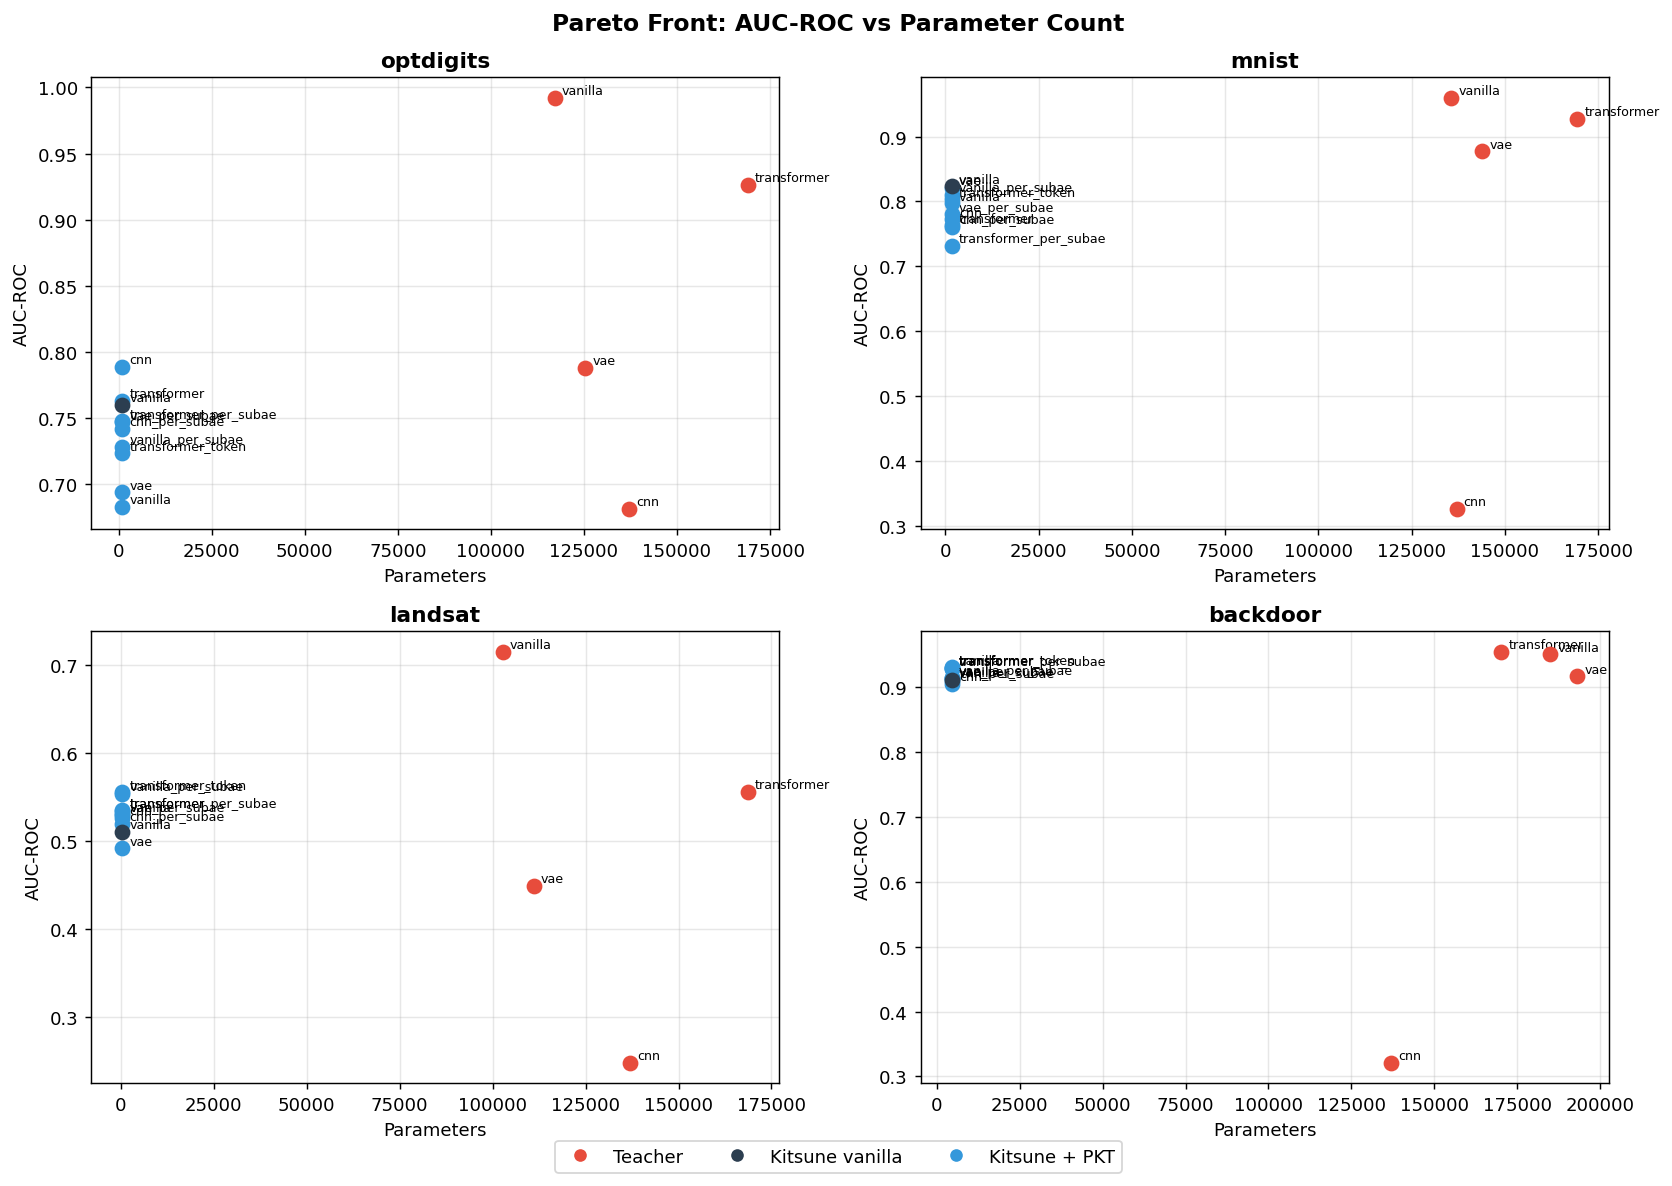

In [39]:
# Pareto plot: AUC-ROC vs parameter count (2×2 grid, one panel per dataset)
means = df.groupby(['dataset', 'model'])[['auc_roc', 'params']].mean().reset_index()

# Colour: teachers vs kitsune variants
def model_color(m):
    if m in TEACHERS:
        return '#e74c3c'        # red — teacher
    elif m == BASELINE:
        return '#2c3e50'        # dark — baseline student
    else:
        return '#3498db'        # blue — PKT student

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=False)
axes = axes.flatten()

for ax, dataset in zip(axes, DATASETS):
    sub = means[means['dataset'] == dataset]
    for _, row in sub.iterrows():
        color = model_color(row['model'])
        ax.scatter(row['params'], row['auc_roc'], color=color, s=60, zorder=3)
        ax.annotate(
            row['model'].replace('kitsune_', '').replace('pkt_', ''),
            (row['params'], row['auc_roc']),
            fontsize=7, xytext=(4, 2), textcoords='offset points'
        )
    ax.set_title(dataset, fontweight='bold')
    ax.set_xlabel('Parameters')
    ax.set_ylabel('AUC-ROC')
    ax.grid(True, alpha=0.3)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='Teacher'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2c3e50', markersize=8, label='Kitsune vanilla'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=8, label='Kitsune + PKT'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Pareto Front: AUC-ROC vs Parameter Count', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pareto.png', dpi=150, bbox_inches='tight')
plt.show()

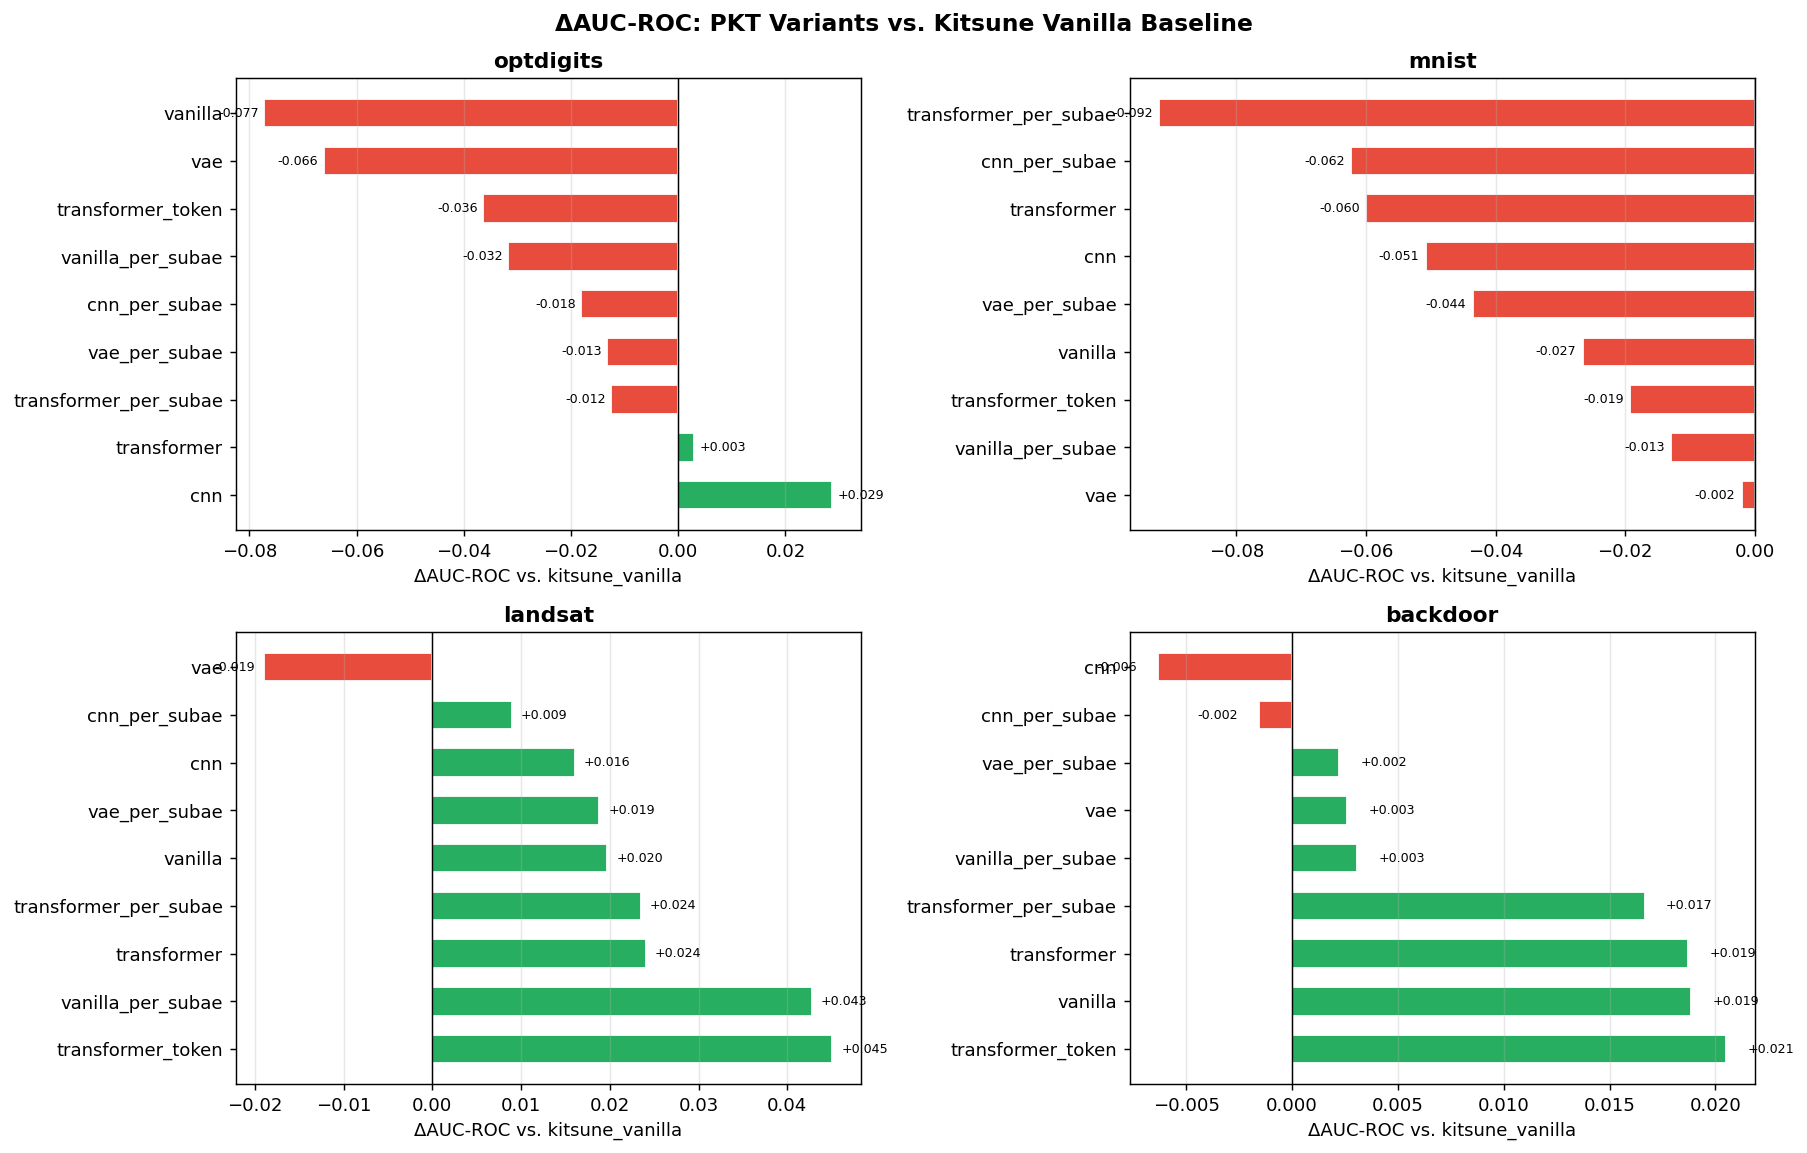

In [40]:
# Delta AUC-ROC: PKT variants vs. kitsune_vanilla baseline (per dataset)
mean_auc = df.groupby(['dataset', 'model'])['auc_roc'].mean().unstack('model')

pkt_models = [m for m in mean_auc.columns if m.startswith('kitsune_pkt')]
delta = mean_auc[pkt_models].subtract(mean_auc[BASELINE], axis=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=False)
axes = axes.flatten()

for ax, dataset in zip(axes, DATASETS):
    row = delta.loc[dataset].sort_values(ascending=False)
    colors = ['#27ae60' if v >= 0 else '#e74c3c' for v in row.values]
    bars = ax.barh(
        [m.replace('kitsune_pkt_', '') for m in row.index],
        row.values,
        color=colors,
        edgecolor='white',
        height=0.6
    )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(dataset, fontweight='bold')
    ax.set_xlabel('ΔAUC-ROC vs. kitsune_vanilla')
    ax.grid(True, axis='x', alpha=0.3)
    # Annotate bar values
    for bar, val in zip(bars, row.values):
        ax.text(
            val + (0.001 if val >= 0 else -0.001),
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=7
        )

plt.suptitle('ΔAUC-ROC: PKT Variants vs. Kitsune Vanilla Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'delta_auc.png', dpi=150, bbox_inches='tight')
plt.show()

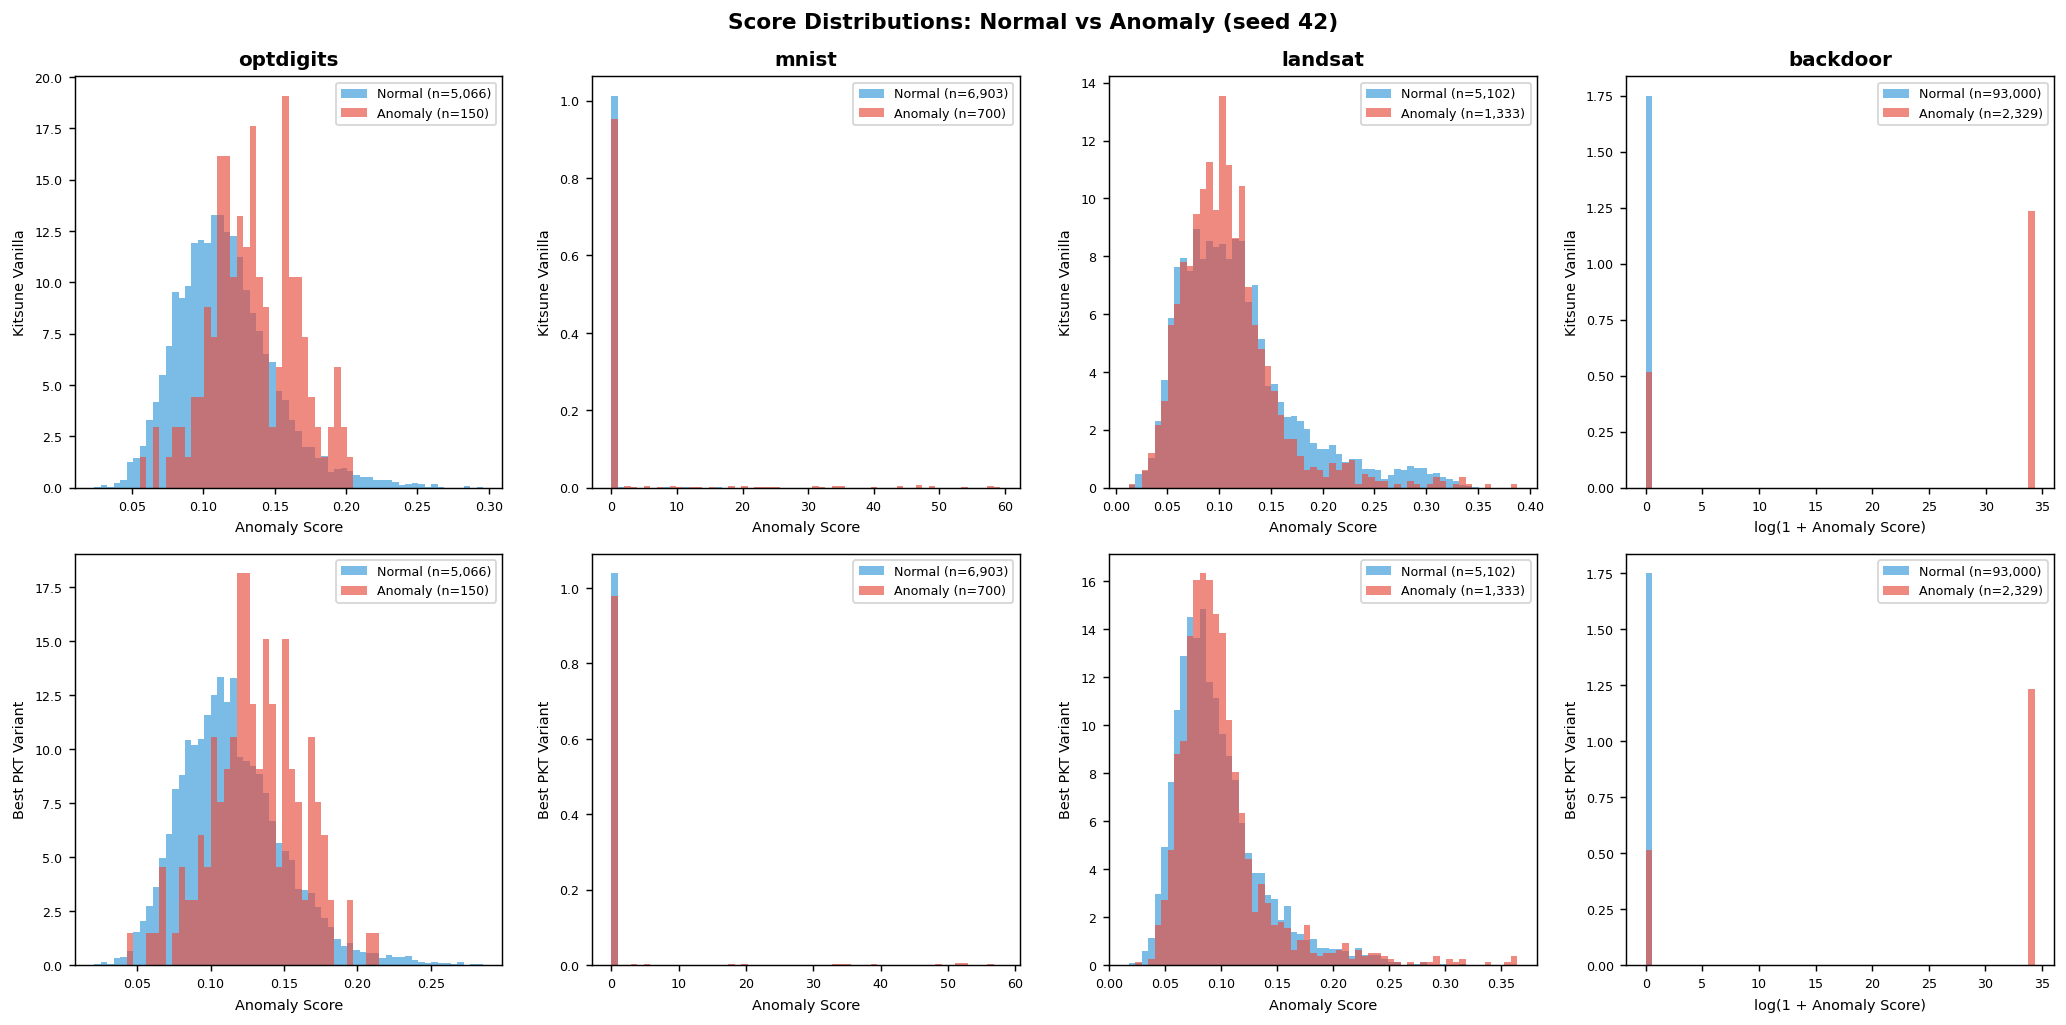

In [41]:
import sys
sys.path.insert(0, str(Path('..').resolve()))

import torch
from models.kitsune import KitsunePyTorch
from data.loader import load_dataset

LOG_SCALE_DATASETS = {'backdoor'}

def get_scores(dataset: str, model_name: str, seed: int):
    ckpt_path = Path('..') / 'checkpoints' / f'{dataset}_{model_name}_seed{seed}.pt'
    if not ckpt_path.exists():
        return None, None
    _, _, test_loader, cfg = load_dataset(dataset, batch_size=512, seed=seed)
    model = KitsunePyTorch(cfg['n_features'], cfg['k_groups'])
    ckpt = torch.load(ckpt_path, map_location='cpu')
    state_dict = ckpt['state_dict'] if isinstance(ckpt, dict) and 'state_dict' in ckpt else ckpt
    model.load_state_dict(state_dict)
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            all_scores.append(model.get_anomaly_score(x).numpy())
            all_labels.append(y.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)


COMPARISONS = {
    'optdigits': ('kitsune_vanilla', 'kitsune_pkt_cnn'),
    'mnist':     ('kitsune_vanilla', 'kitsune_pkt_vae'),
    'landsat':   ('kitsune_vanilla', 'kitsune_pkt_transformer_token'),
    'backdoor':  ('kitsune_vanilla', 'kitsune_pkt_transformer_token'),
}
SEED = 42

fig, axes = plt.subplots(2, len(DATASETS), figsize=(16, 8))

for col, dataset in enumerate(DATASETS):
    baseline_name, pkt_name = COMPARISONS[dataset]
    use_log = dataset in LOG_SCALE_DATASETS

    for row, (model_name, title) in enumerate([
        (baseline_name, 'Kitsune Vanilla'),
        (pkt_name,      'Best PKT Variant'),
    ]):
        ax = axes[row, col]
        scores, labels = get_scores(dataset, model_name, SEED)

        if scores is None:
            ax.text(0.5, 0.5, f'Checkpoint\nnot found:\n{model_name}',
                    ha='center', va='center', transform=ax.transAxes, color='gray', fontsize=8)
        else:
            if use_log:
                scores = np.log1p(scores)
                xlabel = 'log(1 + Anomaly Score)'
            else:
                xlabel = 'Anomaly Score'

            # Shared bin edges so both classes use the same x-range
            bins = np.histogram_bin_edges(scores, bins=60)

            ax.hist(scores[labels == 0], bins=bins, alpha=0.65, color='#3498db',
                    label=f'Normal (n={int((labels==0).sum()):,})', density=True)
            ax.hist(scores[labels == 1], bins=bins, alpha=0.65, color='#e74c3c',
                    label=f'Anomaly (n={int((labels==1).sum()):,})', density=True)
            ax.legend(fontsize=7)
            ax.set_xlabel(xlabel, fontsize=8)

        if row == 0:
            ax.set_title(dataset, fontweight='bold', fontsize=11)
        ax.set_ylabel(title, fontsize=8)
        ax.tick_params(labelsize=7)

plt.suptitle(f'Score Distributions: Normal vs Anomaly (seed {SEED})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'score_histograms.png', dpi=150, bbox_inches='tight')
plt.show()